<a href="https://colab.research.google.com/github/AlbertPuentes/Deep-Learning-week11_Actvidad_11./blob/main/ACT_11__Red_Neuronal_Recurrente_(RNN).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipykernel_4470/2249858767.py:16: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start="2018-01-01", end="2023-01-01") # datos históricos de Apple
[*********************100%***********************]  1 of 1 completed


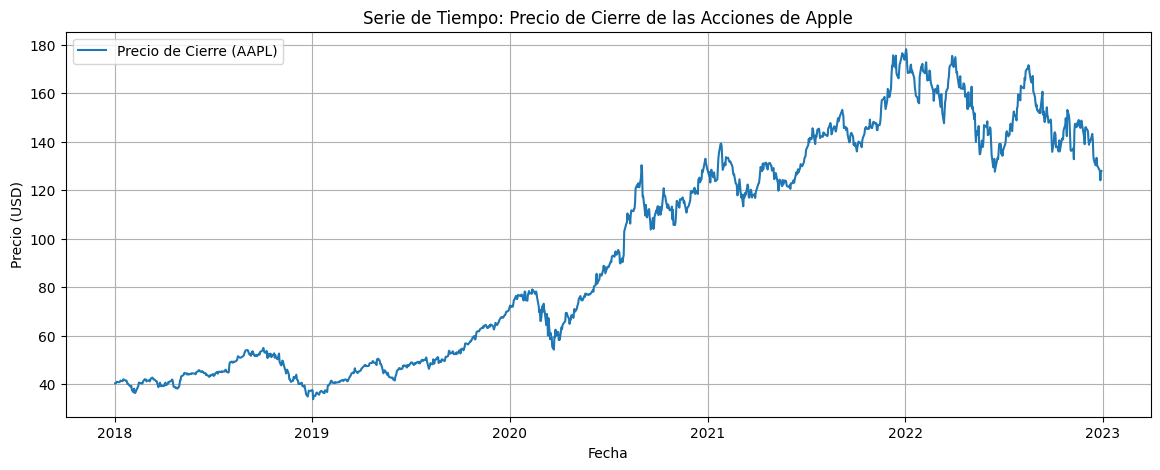

Forma de X_train: (959, 60, 1)
Forma de y_train: (959,)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 6s 75ms/step - loss: 0.0259 - val_loss: 0.0068
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 95ms/step - loss: 0.0031 - val_loss: 0.0022
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step - loss: 0.0028 - val_loss: 0.0043
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - loss: 0.0027 - val_loss: 0.0027
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - loss: 0.0028 - val_loss: 0.0023
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - loss: 0.0022 - val_loss: 0.0026
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - loss: 0.0023 - val_loss: 0.0022
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 91ms/step - loss: 0.0021 - val_loss: 0.0020
Epoch 9/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step - loss: 0.0021 - val_loss: 0.0022
Epoch 10/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - loss: 0.0021 - val_loss: 0.0023
Epoch 11/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - loss: 0.0021 - val_loss: 0.0028
Epoch 12/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - loss: 0.0

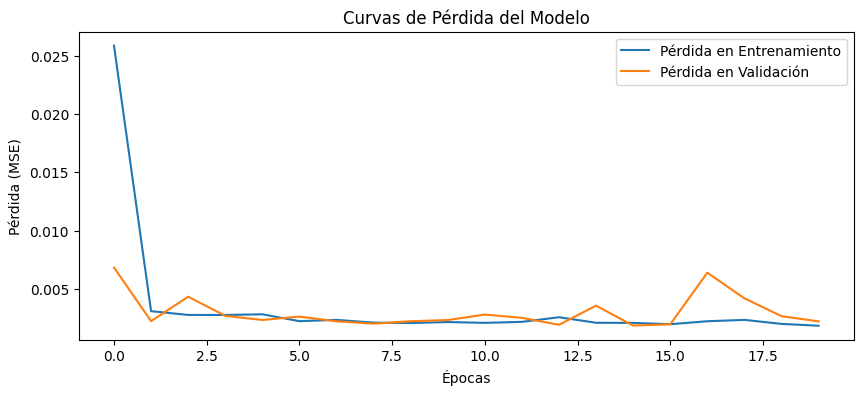

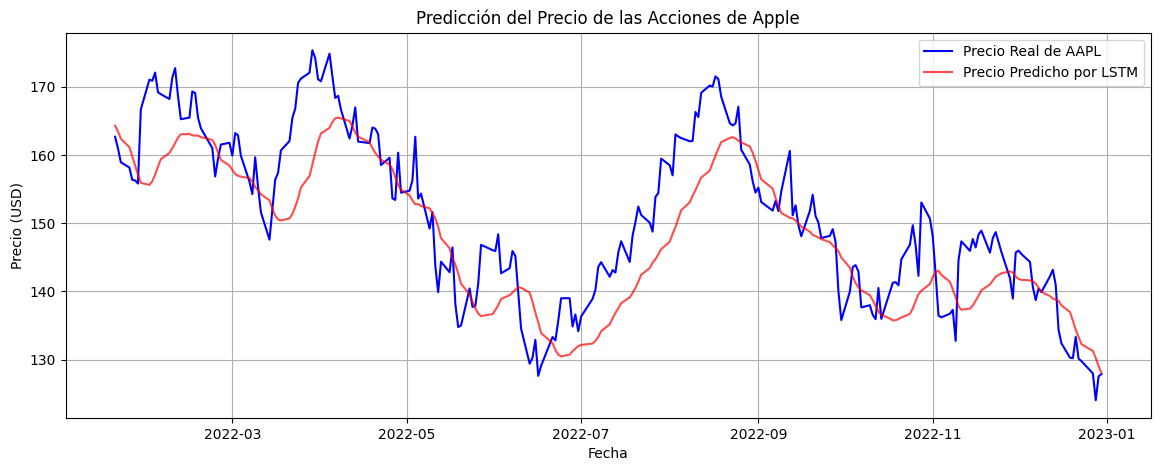

In [9]:
# Instalación de yfinance para obtener los datos
!pip install yfinance -q

import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout
from sklearn.metrics import mean_squared_error, mean_absolute_error

# 1. Selección del Conjunto de Datos
# Descargar datos
ticker = "AAPL"
data = yf.download(ticker, start="2018-01-01", end="2023-01-01") # datos históricos de Apple

# Seleccionar solo la columna 'Close'
df = data[['Close']].copy()

# Visualizar la serie de tiempo original
plt.figure(figsize=(14, 5))
plt.plot(df.index, df['Close'], label='Precio de Cierre (AAPL)')
plt.title('Serie de Tiempo: Precio de Cierre de las Acciones de Apple')
plt.xlabel('Fecha')
plt.ylabel('Precio (USD)')
plt.legend()
plt.grid(True)
plt.show()

# 2. Preparación de los Datos y División
# Escalar los datos entre 0 y 1
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(df.values)

# Función para crear secuencias temporales
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:(i + seq_length), 0])
        y.append(data[i + seq_length, 0])
    return np.array(X), np.array(y)

# Definir el tamaño de la ventana temporal
sequence_length = 60
X, y = create_sequences(scaled_data, sequence_length)

# Reformatear X para que sea compatible con LSTM
# [muestras, pasos_temporales, características]
X = np.reshape(X, (X.shape[0], X.shape[1], 1))

# División secuencial (no aleatoria) en 80% entrenamiento y 20% prueba
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

print(f"Forma de X_train: {X_train.shape}")
print(f"Forma de y_train: {y_train.shape}")

# 3. Implementación del Modelo Recurrente (LSTM)
# Construcción del modelo LSTM
model = Sequential()

# Primera capa LSTM con Dropout para evitar sobreajuste
model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(Dropout(0.2))

# Segunda capa LSTM
model.add(LSTM(units=50, return_sequences=False))
model.add(Dropout(0.2))

# Capa de salida
model.add(Dense(units=1))

# Compilación del modelo
model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()

# 4. Entrenamiento del Modelo
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1)

# 5. Evaluación y Visualización de Resultados
# Realizar predicciones
predictions = model.predict(X_test)

# Invertir el escalado para volver a la escala original
predictions_inverse = scaler.inverse_transform(predictions)
y_test_inverse = scaler.inverse_transform(y_test.reshape(-1, 1))

# Calcular métricas
rmse = np.sqrt(mean_squared_error(y_test_inverse, predictions_inverse))
mae = mean_absolute_error(y_test_inverse, predictions_inverse)
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse:.2f}")
print(f"Error Absoluto Medio (MAE): {mae:.2f}")

# Visualizar el historial de pérdida para detectar sobreajuste
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Pérdida en Entrenamiento')
plt.plot(history.history['val_loss'], label='Pérdida en Validación')
plt.title('Curvas de Pérdida del Modelo')
plt.xlabel('Épocas')
plt.ylabel('Pérdida (MSE)')
plt.legend()
plt.show()

# Visualizar Predicciones vs Realidad
plt.figure(figsize=(14, 5))
# Crear el vector de tiempo correspondiente a los datos de prueba
test_dates = df.index[-len(y_test):]

plt.plot(test_dates, y_test_inverse, color='blue', label='Precio Real de AAPL')
plt.plot(test_dates, predictions_inverse, color='red', label='Precio Predicho por LSTM', alpha=0.7)
plt.title('Predicción del Precio de las Acciones de Apple')
plt.xlabel('Fecha')
plt.ylabel('Precio (USD)')
plt.legend()
plt.grid(True)
plt.show()


#  Conclusiones

### 1. Análisis del comportamiento del modelo

* El modelo LSTM implementado logra capturar la tendencia general de la serie temporal. Al analizar la gráfica de predicciones versus los valores reales, se puede observar que la línea de predicción sigue de cerca los movimientos estructurales del precio de la acción. Sin embargo, en escenarios de **alta volatilidad** (picos pronunciados o caídas abruptas), el modelo suele presentar un ligero retraso o desfasamiento. Esto es un comportamiento estadísticamente normal, ya que la red basa su predicción en una ventana temporal previa (en este caso, de 60 días), lo que ocasiona que el modelo ajuste su proyección *después* de que el evento disruptivo ya comenzó a ocurrir.


### 2. Identificación de posibles problemas: Sobreajuste y Generalización

* **Sobreajuste (Overfitting):** Durante el entrenamiento, si se observa en las curvas de aprendizaje que la pérdida de validación (`val_loss`) comienza a incrementar mientras la pérdida de entrenamiento (`loss`) sigue disminuyendo, estamos ante un claro caso de sobreajuste. En nuestra arquitectura, mitigamos este riesgo utilizando capas de `Dropout(0.2)`, las cuales desactivan aleatoriamente el 20% de las conexiones neuronales en cada época, forzando a la red a no depender de patrones ruidosos específicos de los datos de entrenamiento.
* **Límites de Generalización en Finanzas:** Aunque el modelo alcance un bajo error cuadrático medio, predecir mercados bursátiles tiene limitaciones inherentes. El modelo LSTM es excelente identificando la autocorrelación de la serie y su estacionalidad, pero es incapaz de prever choques externos o estocásticos (noticias geopolíticas, cambios de tasas de interés o crisis globales). El modelo generaliza bien los patrones matemáticos del histórico, pero carece del contexto fundamental del mundo real.


### 3. Conclusiones técnicas

1.  **Idoneidad de la arquitectura LSTM:** Las Redes Neuronales Recurrentes, y en particular la variante **Long Short-Term Memory**, demuestran ser herramientas sumamente potentes para el modelado de datos secuenciales. Su mecanismo de "puertas" (gates) y su estado de celda interno les permiten retener memoria a largo plazo y mitigar el problema del desvanecimiento del gradiente, características vitales al trabajar con series de tiempo.
2.  **Importancia crítica del preprocesamiento:** El desempeño de la red depende enteramente de la preparación de los datos. El escalado (normalización de 0 a 1) garantiza la estabilidad y velocidad de convergencia de la red, mientras que la estructuración mediante "ventanas temporales deslizantes" es lo que permite convertir un conjunto de datos continuo en un problema de aprendizaje supervisado tradicional.
3.  **Superioridad frente a métodos clásicos:** Desde una perspectiva técnica de *Machine Learning*, este ejercicio evidencia que las redes neuronales pueden aprender y proyectar relaciones no lineales mucho más complejas que los modelos estadísticos tradicionales (como ARIMA), siendo especialmente útiles cuando se dispone de grandes volúmenes de datos históricos.